# Basic Machine Learning for IoT Fundamentals

### 0. Install libraries and repositories for this experiment

In [3]:
!pip install numpy pandas matplotlib seaborn scikit-learn influxdb-client[extra] --break-system-packages

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.9 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 8.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 9.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 74.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 83.8 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 86.2 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 84.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.6/362.6 kB 42.8 MB/s eta 0:0

### 1. Import libraries and repositories

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from influxdb_client import InfluxDBClient
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor

In [5]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### 2. Dataset Mockup (Temperature and Humidity)

In [6]:
np.random.seed(42)

temperature = np.random.uniform(20, 40, 100)

noise = np.random.normal(0, 5, 100)
humidity = 120 - (1.8 * temperature) + noise

df = pd.DataFrame({
    'Temperature': temperature,
    'Humidity': humidity
})
print(df.head())

   Temperature   Humidity
0    27.490802  70.951791
1    39.014286  48.279248
2    34.639879  58.107022
3    31.973170  52.510450
4    23.120373  77.284970


### 3. Exploratory Data Analysis with Scatter Plot

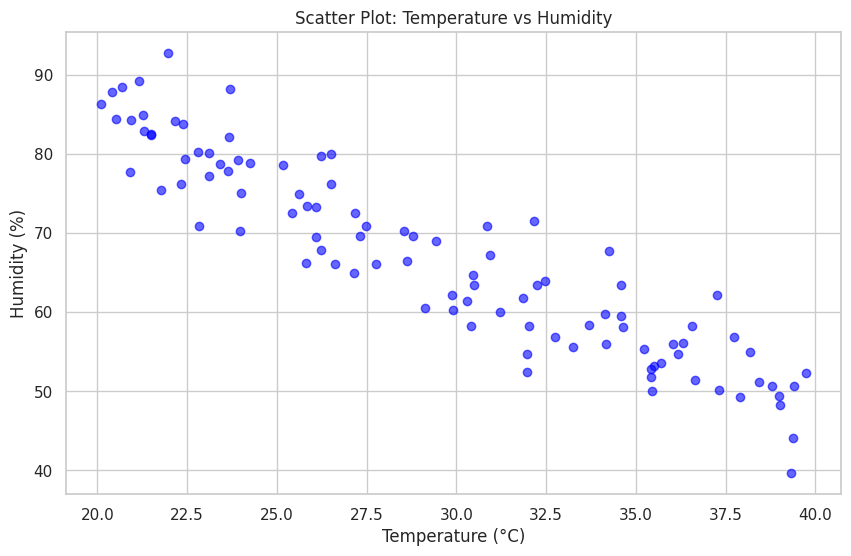

In [7]:
plt.scatter(df['Temperature'], df['Humidity'], color='blue', alpha=0.6)
plt.title('Scatter Plot: Temperature vs Humidity')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.show()

### 4. Linear Regression Model

In [8]:
X = df[['Temperature']].values
Y = df['Humidity'].values

model = LinearRegression()
model.fit(X, Y)

slope = model.coef_[0]
intercept = model.intercept_

print(f"Slope (m): {slope:.4f}")
print(f"Intercept (c): {intercept:.4f}")

Slope (m): -1.9149
Intercept (c): 123.3743


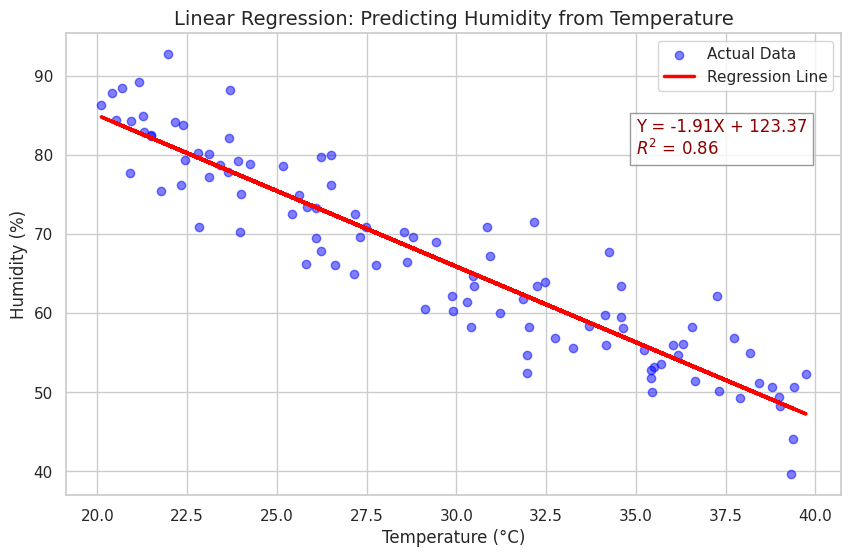

In [9]:
Y_pred = model.predict(X)

r2 = r2_score(Y, Y_pred)

plt.scatter(X, Y, color='blue', label='Actual Data', alpha=0.5)

plt.plot(X, Y_pred, color='red', linewidth=2.5, label='Regression Line')

equation_text = f'Y = {slope:.2f}X + {intercept:.2f}\n$R^2$ = {r2:.2f}'

plt.text(35, 80, equation_text, fontsize=12, color='darkred', 
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.title('Linear Regression: Predicting Humidity from Temperature', fontsize=14)
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Humidity (%)', fontsize=12)
plt.legend()
plt.show()

### 5. Polynomial Regression Model

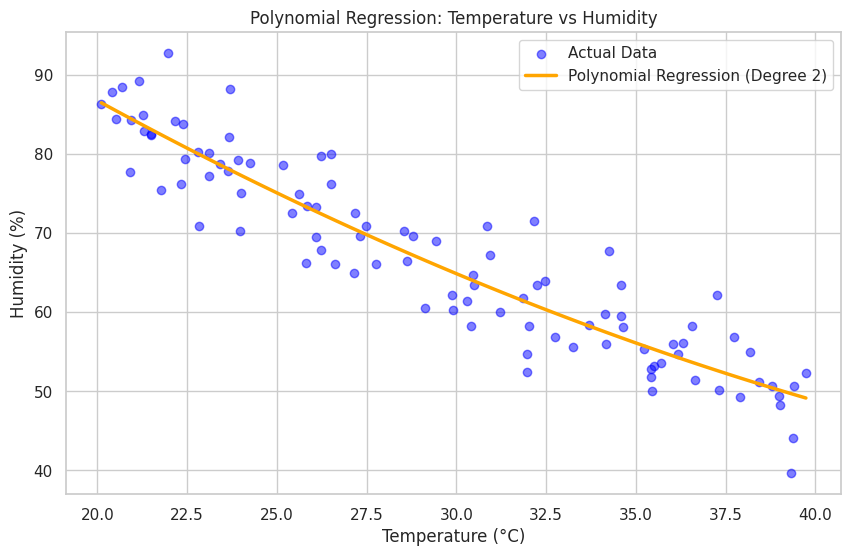

In [10]:
poly_converter = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_converter.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, Y)

X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_plot_poly = poly_converter.transform(X_plot)
Y_plot_pred = poly_model.predict(X_plot_poly)

plt.scatter(X, Y, color='blue', alpha=0.5, label='Actual Data')
plt.plot(X_plot, Y_plot_pred, color='orange', linewidth=2.5, label='Polynomial Regression (Degree 2)')

plt.title('Polynomial Regression: Temperature vs Humidity')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.legend()
plt.show()

### 6. Logistic Regression Model

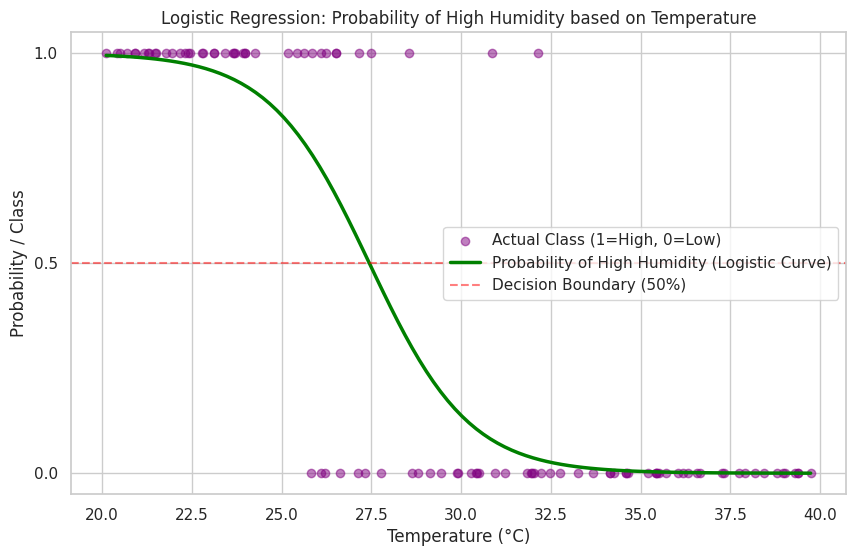

In [11]:
threshold = 70.0
Y_class = np.where(Y > threshold, 1, 0)

log_model = LogisticRegression()
log_model.fit(X, Y_class)

Y_prob = log_model.predict_proba(X_plot)[:, 1]

plt.scatter(X, Y_class, color='purple', alpha=0.5, label='Actual Class (1=High, 0=Low)')
plt.plot(X_plot, Y_prob, color='green', linewidth=2.5, label='Probability of High Humidity (Logistic Curve)')

plt.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Decision Boundary (50%)')
plt.title('Logistic Regression: Probability of High Humidity based on Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Probability / Class')
plt.yticks([0, 0.5, 1])
plt.legend()
plt.show()

### 7. Scikit-Learn Model - Decision Tree Regression 

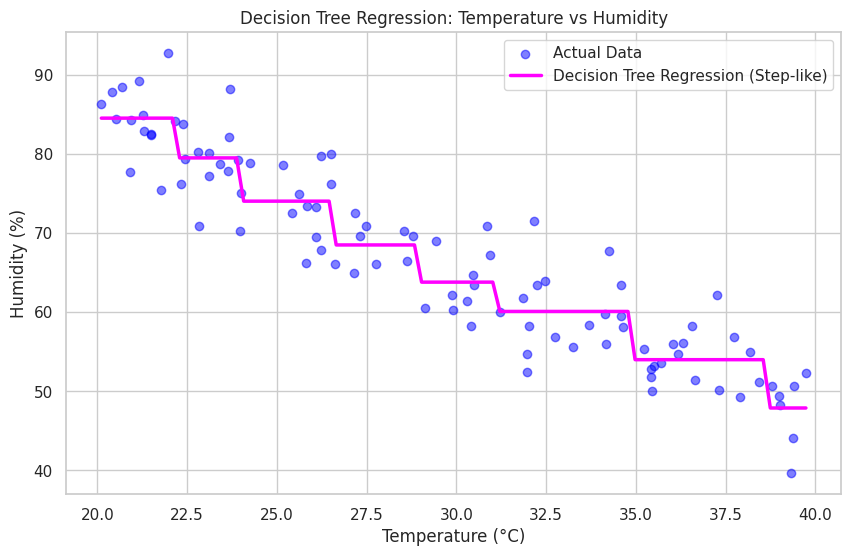

In [12]:
tree_model = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_model.fit(X, Y)

Y_tree_pred = tree_model.predict(X_plot)

plt.scatter(X, Y, color='blue', alpha=0.5, label='Actual Data')
plt.plot(X_plot, Y_tree_pred, color='magenta', linewidth=2.5, label='Decision Tree Regression (Step-like)')

plt.title('Decision Tree Regression: Temperature vs Humidity')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.legend()
plt.show()

### 8. InfluxDB connects and queries the database for a dataset (hands-on project)

In [ ]:
URL = "http://localhost:8086"
TOKEN = "your-influxdb-token"
ORG = "your-org"
BUCKET = "your-bucket"

client = InfluxDBClient(url=URL, token=TOKEN, org=ORG)
query_api = client.query_api()

# query = f"""
# from(bucket: "{BUCKET}")
#   |> range(start: -30d)
#   |> filter(fn: (r) => r["_measurement"] == "sensor_data")
#   |> filter(fn: (r) => r["_field"] == "temperature" or r["_field"] == "humidity")
#   |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
#   |> drop(columns: ["_start", "_stop", "_measurement"])
# """


df = query_api.query_data_frame(query, org=ORG)

cols_to_keep = ['_time', 'temperature', 'humidity']
df = df[[col for col in cols_to_keep if col in df.columns]]
df = df.dropna()
print(df.head())